<a href="https://colab.research.google.com/github/hidnira-lab/introduce-data-science/blob/main/linear-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Linear Regression
- Hidayat Nur Hijrah (24523201)
- Muhammad Farhan Haafidh Abror (24523115)
- Ahmad Dzaky Al Farras (24523282)

## 1. Persiapan Data
Dataset yang digunakan adalah **Taxi Price Prediction** dari Kaggle (https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction). Dataset ini merepresentasikan data sintetis perjalanan taksi untuk memprediksi harga berdasarkan berbagai faktor.

**Deskripsi Dataset:**
* **Jumlah Data:** Dataset ini terdiri dari total 1.000 baris data (observasi) dan memiliki 11 kolom atribut.
* **Fitur (Variabel Independen):** Secara keseluruhan, dataset ini mencakup berbagai fitur penentu harga seperti `Time_of_Day`, `Day_of_Week`, `Passenger_Count`, `Traffic_Conditions`, `Weather`, `Base_Fare`, `Per_Km_Rate`, `Per_Minute_Rate`, dan `Trip_Duration_Minutes`.

Namun, pada tugas ini, kita akan melakukan *Linear Regression* menggunakan 2 variabel:
* **Fitur / Variabel Independen (X):** `Trip_Distance_km` (Jarak perjalanan)
* **Target / Variabel Dependen (Y):** `Trip_Price` (Harga perjalanan)

In [5]:
# === Import Semua Library ===
# Untuk manipulasi data
import pandas as pd
import numpy as np
# Untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns
# Untuk SCIKIT-LEARN Memisahkan data menjadi Training Set dan Testing Set
from sklearn.model_selection import train_test_split
# Untuk algoritma linear regression
from sklearn.linear_model import LinearRegression
# Metrik untuk mengukur seberapa akurat tebakan model kita
from sklearn.metrics import mean_squared_error, r2_score

# === Load data dari csv yang telah di simpan di dalam GitHub Repo ===
url = 'https://raw.githubusercontent.com/hidnira-lab/introduce-data-science/refs/heads/main/taxi_trip_pricing.csv'
df = pd.read_csv(url)

## 2. Eksplorasi Data (EDA)
Tujuan dari eksplorasi ini adalah untuk melihat bentuk data awal dan membuktikan secara visual apakah benar terdapat hubungan linier (searah) antara jarak perjalanan taksi dengan harga yang harus dibayar.

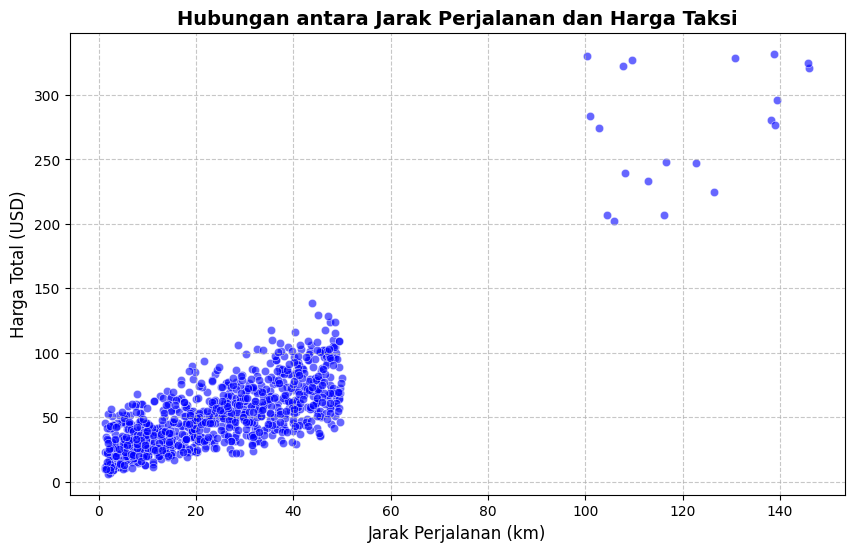

In [6]:
# Membuat figure dengan ukuran yang enak dilihat
plt.figure(figsize=(10, 6))

# Membuat scatter plot menggunakan seaborn
sns.scatterplot(x=df['Trip_Distance_km'], y=df['Trip_Price'], alpha=0.6, color='blue')

# Menambahkan judul dan label yang informatif
plt.title('Hubungan antara Jarak Perjalanan dan Harga Taksi', fontsize=14, fontweight='bold')
plt.xlabel('Jarak Perjalanan (km)', fontsize=12)
plt.ylabel('Harga Total (USD)', fontsize=12)

# Menampilkan grid biar lebih rapi
plt.grid(True, linestyle='--', alpha=0.7)

# Menampilkan grafik
plt.show()

## 3. Pembangunan Model
Pada tahap ini, kita akan membangun model *Machine Learning* menggunakan algoritma *Linear Regression*. Langkah-langkah yang dilakukan adalah:
1. Menentukan variabel fitur (X) dan target (y).
2. Membagi dataset menjadi *Training Set* (80%) dan *Testing Set* (20%). Pembagian ini penting agar model dievaluasi pada data yang belum pernah dilihat sebelumnya.
3. Menginisialisasi dan melatih model `LinearRegression` menggunakan *Training Set*.

In [9]:
# Kita cek dulu ada berapa data yang bolong (NaN) atau Not a Number untuk memastikan bahwa tidak ada data yang kosong pada dataset .csv
print("Jumlah data kosong:")
print(df[['Trip_Distance_km', 'Trip_Price']].isnull().sum())

# Kita buang baris yang ada data kosongnya menggunakan dropna()
df_clean = df.dropna(subset=['Trip_Distance_km', 'Trip_Price'])

# Tentukan Fitur (X) dan Target (y) dengan menggunakan df_clean (data yang sudah bersih)
# X menggunakan kurung siku ganda karena sklearn membutuhkan input 2D array
X = df_clean[['Trip_Distance_km']]
y = df_clean['Trip_Price']

# Membagi data menjadi Training Set (80%) dan Testing Set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan informasi jumlah data yang dibagi
print(f"Jumlah data Training: {len(X_train)} baris")
print(f"Jumlah data Testing: {len(X_test)} baris\n")

# Panggil dan Inisialisasi Model
model = LinearRegression()

# Latih model dengan data Training
model.fit(X_train, y_train)

print("Model Linear Regression berhasil dilatih!")

Jumlah data kosong:
Trip_Distance_km    50
Trip_Price          49
dtype: int64
Jumlah data Training: 720 baris
Jumlah data Testing: 181 baris

Model Linear Regression berhasil dilatih!


## 4. Evaluasi Model
Setelah model dilatih, tahap selanjutnya adalah menguji seberapa baik model tersebut dalam memprediksi data yang belum pernah dilihat sebelumnya (*Testing Set*).

Pada evaluasi ini, kami akan:
1. Melakukan prediksi harga taksi berdasarkan jarak pada data *testing*.
2. Menampilkan persamaan garis regresi yang terbentuk, yaitu nilai **Slope** (kemiringan garis) dan **Intercept** (titik potong pada sumbu Y).
3. Mengukur performa model menggunakan metrik **R-squared ($R^2$) Score** dan **Mean Squared Error (MSE)**.

In [10]:
# Lakukan prediksi pada data testing
y_pred = model.predict(X_test)

# Tampilkan nilai koefisien regresi (slope & intercept)
slope = model.coef_[0]
intercept = model.intercept_

print("=== Persamaan Garis Regresi ===")
print(f"Slope (Kemiringan)   : {slope:.4f}")
print(f"Intercept (Titik Y)  : {intercept:.4f}")
print(f"Rumus: Harga = ({slope:.2f} * Jarak) + {intercept:.2f}\n")

# Hitung R^2 Score dan MSE
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("=== Performa Model ===")
print(f"R-squared Score ($R^2$) : {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

=== Persamaan Garis Regresi ===
Slope (Kemiringan)   : 1.6925
Intercept (Titik Y)  : 10.7848
Rumus: Harga = (1.69 * Jarak) + 10.78

=== Performa Model ===
R-squared Score ($R^2$) : 0.6909
Mean Squared Error (MSE): 634.2833


## 5. Visualisasi Hasil
Untuk mengevaluasi model secara visual, kita akan membuat plot yang membandingkan titik data aktual dari *Testing Set* dengan garis regresi yang dihasilkan oleh model (hasil prediksi). Garis lurus ini merepresentasikan pola terbaik yang ditemukan oleh algoritma dari data *Training*.

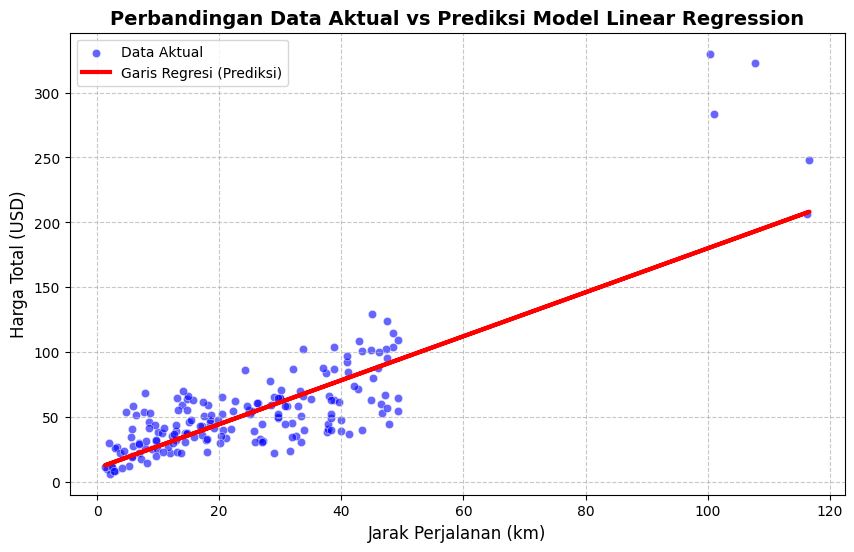

In [11]:
# Membuat figure
plt.figure(figsize=(10, 6))

# Plot titik data aktual dari Testing Set (Warna Biru)
sns.scatterplot(x=X_test['Trip_Distance_km'], y=y_test, color='blue', label='Data Aktual', alpha=0.6)

# Plot garis regresi hasil prediksi (Warna Merah)
# Kita hubungkan nilai X_test dengan y_pred (hasil tebakan)
plt.plot(X_test['Trip_Distance_km'], y_pred, color='red', linewidth=3, label='Garis Regresi (Prediksi)')

# Menambahkan detail grafik
plt.title('Perbandingan Data Aktual vs Prediksi Model Linear Regression', fontsize=14, fontweight='bold')
plt.xlabel('Jarak Perjalanan (km)', fontsize=12)
plt.ylabel('Harga Total (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Menampilkan visualisasi
plt.show()

## 6. Analisis dan Kesimpulan
Berdasarkan hasil evaluasi model *Simple Linear Regression* yang telah dilatih, berikut adalah interpretasinya:

**1. Makna Slope dan Intercept**
* **Intercept (10.7848):** Secara matematis, ini adalah nilai Harga (Y) saat Jarak (X) bernilai 0. Dalam konteks operasional taksi, ini sangat logis dan bisa diartikan sebagai tarif awal (argo buka pintu / *base fare*). Jadi, saat penumpang baru masuk, argo secara teoritis berada di angka sekitar 10.78 USD.
* **Slope (1.6925):** Ini merepresentasikan tingkat kemiringan atau tarif per kilometer. Artinya, untuk setiap penambahan jarak perjalanan sejauh **1 km**, biaya taksi akan bertambah sekitar **1.69 USD**.

**2. Seberapa baik model memprediksi data?**
* Model memperoleh nilai **$R^2$ Score sebesar 0.6909** (atau sekitar **69.09%**).
* Artinya, variabel Jarak (`Trip_Distance_km`) mampu menjelaskan 69.09% dari perubahan Harga Taksi (`Trip_Price`). Sisa **30.91%** varians harga dipengaruhi oleh faktor-faktor lain di luar model ini (seperti tingkat kemacetan, cuaca, atau waktu pemesanan). Untuk sebuah model sederhana yang hanya menggunakan 1 variabel fitur, performa 69% ini sudah tergolong cukup baik dan fungsional.

**3. Indikasi Overfitting atau Underfitting**
* Model ini **tidak mengalami overfitting**. Algoritma *Linear Regression* menghasilkan garis lurus yang kaku, sehingga sangat sulit baginya untuk mengingat titik-titik data *training* secara berlebihan.
* Namun, model ini menunjukkan sedikit indikasi **underfitting**. Di dunia nyata, penetapan harga taksi melibatkan banyak variabel kompleks (multivariabel). Dengan hanya menggunakan satu variabel (Jarak), model ini menjadi terlalu sederhana dan kehilangan kemampuan untuk menangkap pengaruh dari fitur penting lainnya di dalam dataset.